###################################################################################################

## https://chiliubio.github.io/microeco_tutorial/

## Cargar librería de file2meco e importar datos 

In [7]:
# Cargar libreria librery
library(file2meco)

In [9]:
# importar dada2_table.qza, metadata.txt y taxonomy.qza
abund_file_path <- "../qiime2_diabeticos/qza/dada2_table.qza"
sample_file_path <- "../data/metadata_diabetico.txt"
taxonomy_file_path <- "../qiime2_diabeticos/qza/taxonomy.qza"
# add phylogenetic tree and fasta
tree_data <- "../qiime2_diabeticos/qza/rooted_tree.qza"
rep_data <- "../qiime2_diabeticos/qza/dada2_rep_set.qza"

In [11]:
Diabeticos <- qiime2meco(abund_file_path, 
                    sample_table = sample_file_path, 
                    taxonomy_table = taxonomy_file_path, 
                    phylo_tree = tree_data, 
                    rep_fasta = rep_data, auto_tidy = TRUE)
Diabeticos

microtable-class object:
sample_table have 50 rows and 7 columns
otu_table have 4556 rows and 50 columns
tax_table have 4556 rows and 7 columns
phylo_tree have 4556 tips
rep_fasta have 4556 sequences

## Cargar libreria de microeco y demás dependencias para el análisis de los datos

In [20]:
library(microeco)
# use pipe operator in magrittr package
library(magrittr)
# fix the random number generation to make the results repeatable
set.seed(123)
# make the plotting background same with the tutorial
library(ggplot2)
theme_set(theme_bw())

In [22]:
head(Diabeticos$sample_table, 4)

,Age,Sex,Diabetic,Comorbidities,Smoker,Stage,Samples
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
12802.CUS-IMSS-100.assembled.fastq,37,Male,Yes,No,Yes,Moderate,CUS-IMSS-100.assembled.fastq
12802.CUS-IMSS-111.assembled.fastq,73,Male,Yes,Hypertension,No,Mild,CUS-IMSS-111.assembled.fastq
12802.CUS-IMSS-113.assembled.fastq,66,Female,Yes,No,Yes,Mild,CUS-IMSS-113.assembled.fastq
12802.CUS-IMSS-118.assembled.fastq,57,Female,Yes,Other,No,Moderate,CUS-IMSS-118.assembled.fastq


In [24]:
head(Diabeticos$otu_table, 4)

,12802.CUS-IMSS-100.assembled.fastq,12802.CUS-IMSS-111.assembled.fastq,12802.CUS-IMSS-113.assembled.fastq,12802.CUS-IMSS-118.assembled.fastq,12802.CUS-IMSS-12.assembled.fastq,12802.CUS-IMSS-125.assembled.fastq,12802.CUS-IMSS-13.assembled.fastq,12802.CUS-IMSS-14.assembled.fastq,12802.CUS-IMSS-145.assembled.fastq,12802.CUS-IMSS-152.assembled.fastq,⋯,12802.CUS-IMSS-392.assembled.fastq,12802.CUS-IMSS-396.assembled.fastq,12802.CUS-IMSS-416.assembled.fastq,12802.CUS-IMSS-55.assembled.fastq,12802.CUS-IMSS-68.assembled.fastq,12802.CUS-IMSS-71.assembled.fastq,12802.CUS-IMSS-90.assembled.fastq,12802.CUS-IMSS-94.assembled.fastq,12802.CUS-IMSS-96.assembled.fastq,12802.CUS-IMSS-97.assembled.fastq
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
e64225aff8a25ed792af2e001e64e1a6,6808,11538,7492,14072,7389,8807,3100,2032,1821,8613,⋯,8692,11455,3578,3338,4395,2931,5114,5028,22719,9681
9e2d5f0a1445168e65c96143073cdf97,13681,3402,3572,4671,2322,7921,11215,8508,9178,4309,⋯,13461,395,4373,5735,4354,5063,8154,1009,7011,191
131b19fb7e635cfa13d2c6c5d1539156,7309,1174,441,5133,421,6258,15085,5556,995,17171,⋯,8611,1511,19288,1993,2657,7470,6290,1000,6485,525
e96f7c2052fead4c208e4fc1909eeadb,5162,745,1002,929,1862,4115,6471,4937,5153,2831,⋯,3354,365,909,2129,2470,4193,2668,1139,4295,875


In [26]:
head(Diabeticos$tax_table, 4)

,Kingdom,Phylum,Class,Order,Family,Genus,Species
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
e64225aff8a25ed792af2e001e64e1a6,k__Bacteria,p__Firmicutes,c__Bacilli,o__Lactobacillales,f__Streptococcaceae,g__Streptococcus,s__
9e2d5f0a1445168e65c96143073cdf97,k__Bacteria,p__Firmicutes,c__Negativicutes,o__Veillonellales-Selenomonadales,f__Veillonellaceae,g__Veillonella,s__
131b19fb7e635cfa13d2c6c5d1539156,k__Bacteria,p__Firmicutes,c__Bacilli,o__Lactobacillales,f__Streptococcaceae,g__Streptococcus,s__Streptococcus_salivarius
e96f7c2052fead4c208e4fc1909eeadb,k__Bacteria,p__Firmicutes,c__Negativicutes,o__Veillonellales-Selenomonadales,f__Veillonellaceae,g__Veillonella,s__


In [28]:
# Checar que el sample_table, otu_table and tax_table son data.frame
class(Diabeticos$sample_table)
class(Diabeticos$otu_table)
class(Diabeticos$tax_table)

[1] "data.frame"

[1] "data.frame"

[1] "data.frame"

### Limpieza de datos, checar la siguiente descripción

In [31]:
# Generalmente la tabla taxonómica (tax_table) tiene información desordenada: NA, no identificadas y desconocidadas
# Esta información pued influir en en el cálculo de la abundancia taxonómica y otros análisis basados en taxonomía
# Por lo que se limpia estos datos con la función de "tidy_taxonomy"
# Otro resultado muy importante de esta operación es unificar automáticamente el prefijo taxonómico, 
# por ejemplo, convirtiendo D_1__ en p__ para el nivel de Phylum o agregando p__ al Phylum directamente si no se encuentra ningún prefijo

In [33]:
# make the taxonomic information unified
Diabeticos$tax_table %<>% tidy_taxonomy

In [35]:
class(Diabeticos)

[1] "microtable" "R6"

##  Create an object of microtable class (No es necesario, pero se puede correr para seguir el pipeline)

In [38]:
# Crear un objeto microtable con más información
mt <- microtable$new(sample_table = Diabeticos$sample_table, 
                     otu_table = Diabeticos$otu_table, 
                     tax_table = Diabeticos$tax_table, 
                     phylo_tree = Diabeticos$phylo_tree)
mt

microtable-class object:
sample_table have 50 rows and 7 columns
otu_table have 4556 rows and 50 columns
tax_table have 4556 rows and 7 columns
phylo_tree have 4556 tips

## Crear una copia, para no hacer otra vez todo

In [41]:
######## COPIA
# Para crear una copia de los archivos crudos
mt_raw <- clone(mt)
mt_raw

microtable-class object:
sample_table have 50 rows and 7 columns
otu_table have 4556 rows and 50 columns
tax_table have 4556 rows and 7 columns
phylo_tree have 4556 tips

## Funciones en la clase microtable

### Remover OTUs que no están asignados en el reino de “k__Archaea” or “k__Bacteria”

In [45]:
# usar la funcion de subset para filtrar taxas en "tax_table"
mt$tax_table %<>% base::subset(Kingdom == "k__Archaea" | Kingdom == "k__Bacteria")
mt

microtable-class object:
sample_table have 50 rows and 7 columns
otu_table have 4556 rows and 50 columns
tax_table have 4556 rows and 7 columns
phylo_tree have 4556 tips

In [47]:
# eliminará las líneas que contienen la palabra del taxón independientemente de los rangos taxonómicos 
# e ignorará las mayúsculas y minúsculas en la "tax_table"
mt$filter_pollution(taxa = c("mitochondria", "chloroplast"))
mt

Total 11 features are removed from tax_table ...



microtable-class object:
sample_table have 50 rows and 7 columns
otu_table have 4556 rows and 50 columns
tax_table have 4545 rows and 7 columns
phylo_tree have 4556 tips

In [49]:
mt$tidy_dataset()
mt

microtable-class object:
sample_table have 50 rows and 7 columns
otu_table have 4545 rows and 50 columns
tax_table have 4545 rows and 7 columns
phylo_tree have 4545 tips

In [51]:
# Con la función sample_sums() checamos el número de secuencias en cada muestra
mt$sample_sums() %>% range

[1]  65338 119100

In [53]:
# Usamos 20000 secuencias en cada muestra
mt$rarefy_samples(sample.size = 20000)

589 features are removed because they are no longer present in any sample after random subsampling ...

589 taxa with 0 abundance are removed from the otu_table ...



In [55]:
mt$sample_sums() %>% range

[1] 20000 20000

In [57]:
mt$save_table(dirpath = "../data/basic_files", sep = ",")

Save feature abundance to ../data/basic_files/feature_table.csv ...

Save metadata to ../data/basic_files/sample_table.csv ...

Save taxonomic information to ../data/basic_files/tax_table.csv ...

Save phylogenetic tree to ../data/basic_files/phylo_tree.tre ...



In [59]:
# parametro por defaul (rel = TRUE) indica "relative abundance"
mt$cal_abund()
mt

The result is stored in object$taxa_abund ...



microtable-class object:
sample_table have 50 rows and 7 columns
otu_table have 3956 rows and 50 columns
tax_table have 3956 rows and 7 columns
phylo_tree have 3956 tips
Taxa abundance: calculated for Kingdom,Phylum,Class,Order,Family,Genus,Species 

In [61]:
# Devuelve la lista "taxa_abund" en el objeto
class(mt$taxa_abund)

[1] "list"

In [63]:
# Mostrar parte de la abundancia relativa a nivel de Phylum
mt$taxa_abund$Phylum[1:5, 1:5]

,12802.CUS-IMSS-100.assembled.fastq,12802.CUS-IMSS-111.assembled.fastq,12802.CUS-IMSS-113.assembled.fastq,12802.CUS-IMSS-118.assembled.fastq,12802.CUS-IMSS-12.assembled.fastq
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
k__Bacteria|p__Firmicutes,0.53935,0.42120,0.4212,0.46195,0.41865
k__Bacteria|p__Bacteroidota,0.20180,0.28340,0.2002,0.08640,0.17090
k__Bacteria|p__Actinobacteriota,0.11600,0.07220,0.1121,0.25605,0.06085
k__Bacteria|p__Proteobacteria,0.09190,0.07880,0.1291,0.12495,0.05530
k__Bacteria|p__Fusobacteriota,0.02480,0.08715,0.1036,0.04010,0.20670


In [65]:
# La función save_abund() se puede utilizar para guardar fácilmente el archivo de abundancia de taxones en un lugar local.
mt$save_abund(dirpath = "../data/taxa_abund")

### Checar STMAP, se puede usar estos datos 

### https://beikolab.cs.dal.ca/software/STAMP

In [67]:
# If you want to add Faith's phylogenetic diversity, use PD = TRUE, this will be a little slow
mt_raw$cal_alphadiv(PD = FALSE)

The result is stored in object$alpha_diversity ...



In [69]:
# return alpha_diversity in the object
class(mt_raw$alpha_diversity)

[1] "data.frame"

In [71]:
# Guardar diversidad alfa en undirectory
mt_raw$save_alphadiv(dirpath = "../data/alpha_diversity")

In [73]:
# unifrac = FALSE means do not calculate unifrac metric
# require GUniFrac package installed
mt_raw$cal_betadiv(unifrac = TRUE)
# return beta_diversity list in the object
class(mt_raw$beta_diversity)
# save beta_diversity to a directory
mt_raw$save_betadiv(dirpath = "../data/beta_diversity")

Registered S3 method overwritten by 'rmutil':
  method         from
  print.response httr



Accumulate the abundance along the tree branches...
Compute pairwise distances ...
Completed!


The result is stored in object$beta_diversity ...



[1] "list"

In [74]:
mt_raw

microtable-class object:
sample_table have 50 rows and 7 columns
otu_table have 4556 rows and 50 columns
tax_table have 4556 rows and 7 columns
phylo_tree have 4556 tips
Alpha diversity: calculated for Observed,Chao1,se.chao1,ACE,se.ACE,Shannon,Simpson,InvSimpson,Fisher,Pielou,Coverage 
Beta diversity: calculated for bray,jaccard,wei_unifrac,unwei_unifrac 

# Filtrar abundancia relativa

In [ ]:
# Hacemos un respaldo antes de filtrar los features
mt_v2 <- clone(mt)
mt_v2
# Establecemos la abundancia relativa mayor a 0.001 (0.1%)
mt_v2$filter_taxa(rel_abund = 0.001, freq = 0.1)
mt_v2

################################# HASTA AQUI TERMINA EL FILTRADO #################################

# 4 Composition-based class

## 4.1 trans_abund class

In [90]:
# Crear un objeto trans_abund
# Seleccionar para 15 Phylum abundantes.
t1 <- trans_abund$new(dataset = mt, taxrank = "Genus", ntaxa = 15)
t1

The transformed abundance data is stored in object$data_abund ...



trans_abund object:
data_abund have 11 columns:  Taxonomy, Sample, Abundance, Age, Sex, Diabetic, Comorbidities, Smoker, Stage, Samples, all_mean_abund 
data_abund have total 174 taxa
taxrank:  Genus 
data_taxanames:  Streptococcus, Veillonella, Prevotella, Rothia, Haemophilus, Neisseria, Actinomyces, Leptotrichia, Porphyromonas, Fusobacterium, Megasphaera, Gemella, Alloprevotella, Selenomonas, Granulicatella 

Input colors are not enough to use. Add more colors automatically via color interpolation ...



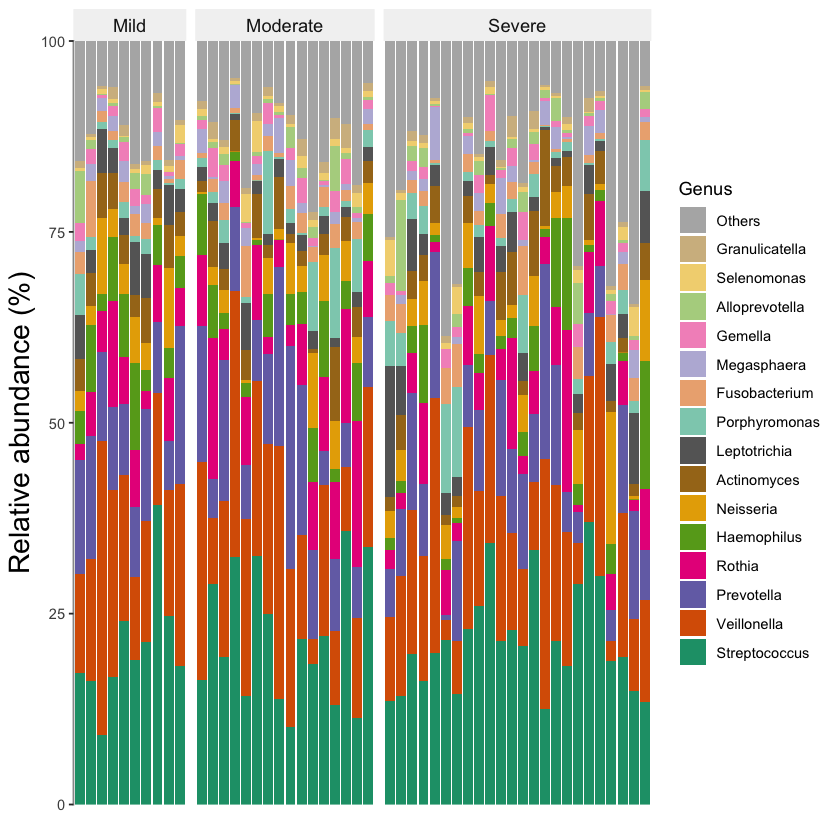

In [92]:
# Como el número de muestra es grande, no mostramos los nombres de las muestras en el eje x,
# usamos "facet" para mostrar la abundancia según los grupos.
t1$plot_bar(others_color = "grey70", facet = "Stage", xtext_keep = FALSE, legend_text_italic = FALSE)
# return a ggplot2 object

In [94]:
# Crear un objeto trans_abund
# Seleccionar para 15 Phylum abundantes.
t2 <- trans_abund$new(dataset = mt, taxrank = "Species", ntaxa = 15)
t2

The transformed abundance data is stored in object$data_abund ...



trans_abund object:
data_abund have 11 columns:  Taxonomy, Sample, Abundance, Age, Sex, Diabetic, Comorbidities, Smoker, Stage, Samples, all_mean_abund 
data_abund have total 225 taxa
taxrank:  Species 
data_taxanames:  Streptococcus_salivarius, Prevotella_melaninogenica, Schaalia_odontolytica, Megasphaera_micronuciformis, Prevotella_pallens, Actinomyces_graevenitzii, Neisseria_perflava, Rothia_mucilaginosa, Prevotella_histicola, Porphyromonas_gingivalis, Fusobacterium_periodonticum, Streptococcus_parasanguinis, Prevotella_jejuni, Prevotella_salivae, Prevotella_veroralis 

Input colors are not enough to use. Add more colors automatically via color interpolation ...



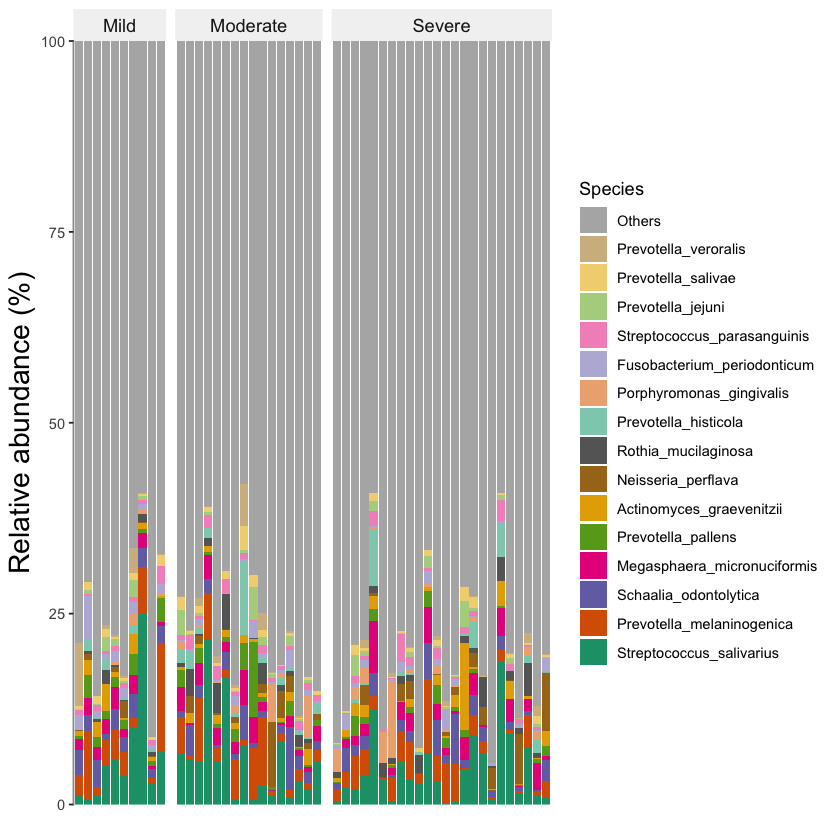

In [96]:
# Como el número de muestra es grande, no mostramos los nombres de las muestras en el eje x,
# usamos "facet" para mostrar la abundancia según los grupos.
t2$plot_bar(others_color = "grey70", facet = "Stage", xtext_keep = FALSE, legend_text_italic = FALSE)
# return a ggplot2 object